# House Price Data Mining Project

## Objective
Analyze housing data and understand factors affecting house prices.


## Steps
- Data cleaning
- Exploratory Data Analysis (EDA)
- Feature correlation analysis
- Predictive modeling

### Dataset train e target distribution

Kaggle House Prices dataset (1460 rows, 81 columns)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("C:\\Users\\mammi\\Desktop\\Python_Projects\\house-price-analysis\\train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


#### Target distribution

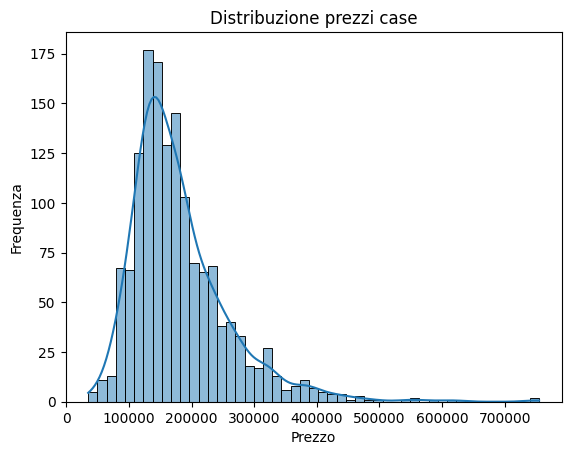

In [7]:
import matplotlib.pyplot as plt

plt.title("Distribuzione prezzi case")
plt.xlabel("Prezzo")
plt.ylabel("Frequenza")
df["SalePrice"].describe()
sns.histplot(df["SalePrice"], kde=True)
plt.show()


### Missing values

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Lot of missing values are concentrated in basement/garage features so are not a problem in the dataset

### Feature correlation analysis

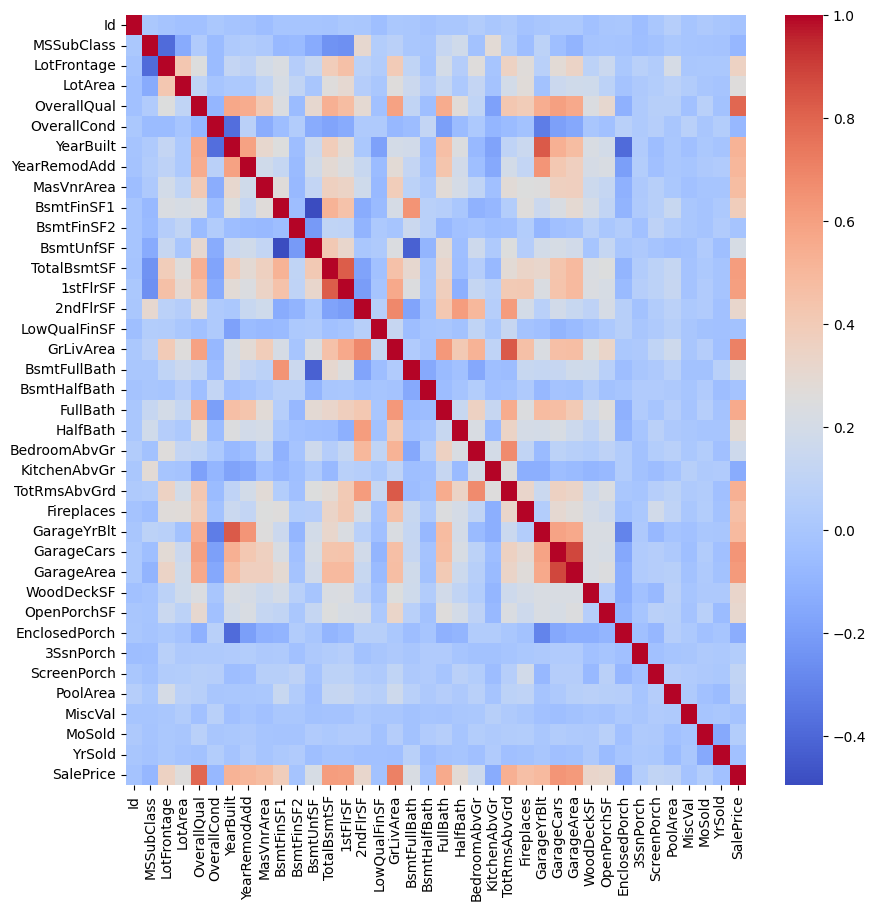

In [9]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

In [10]:
corr = df.corr(numeric_only=True)

corr['SalePrice'].sort_values(ascending=False)


SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

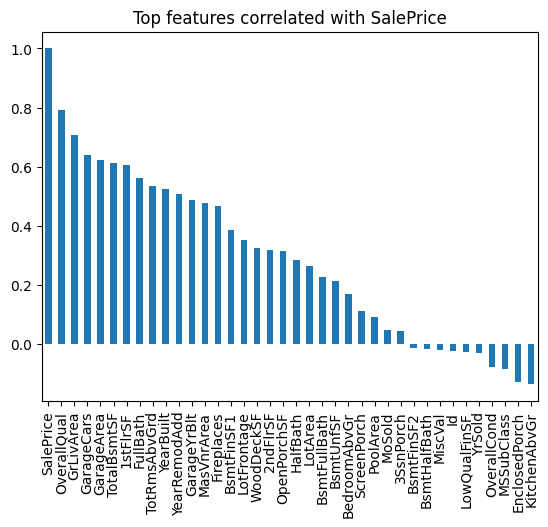

In [60]:
top_corr = corr['SalePrice'].sort_values(ascending=False).head(50)

top_corr.plot(kind='bar')
plt.title("Top features correlated with SalePrice")
plt.show()

The correlation matrix indicates that OverallQual (0.79) and GrLivArea (0.71) are the strongest predictors of sale price. Garage, basement size, fullbath and construction year also display substantial positive correlations. These findings suggest that house quality, size, and modernity are key determinants of property value.

### Exploratory Data Analysis (EDA)

Analysis of neighborhoods

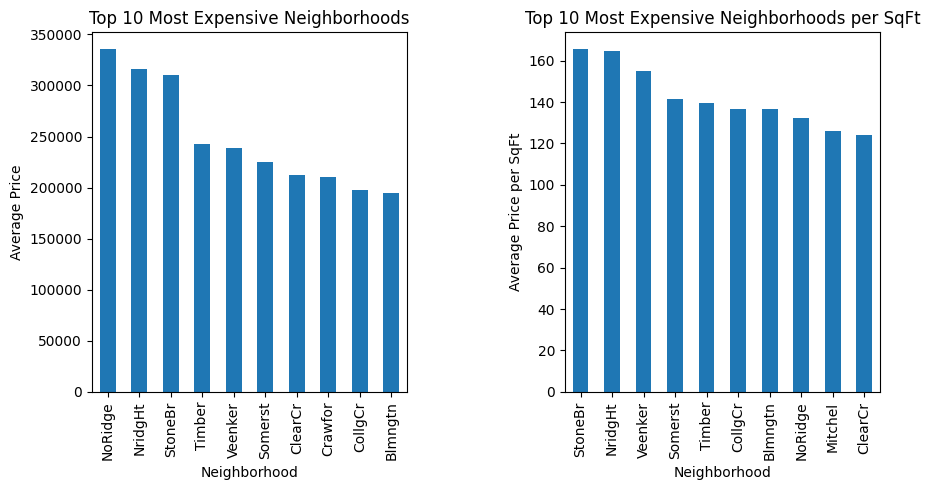

In [12]:
plt.figure(figsize=(9, 5))
plt.subplot(1, 2, 1)

neighborhood_price = df.groupby('Neighborhood')['SalePrice'].mean()

neighborhood_price.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Most Expensive Neighborhoods")
plt.ylabel("Average Price")


plt.subplot(1, 2, 2) 
df['PricePerSqFt'] = df['SalePrice'] / df['GrLivArea']
neighborhood_PricePerSqFt = df.groupby('Neighborhood')['PricePerSqFt'].mean()

neighborhood_PricePerSqFt.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Most Expensive Neighborhoods per SqFt")
plt.ylabel("Average Price per SqFt")
plt.tight_layout()

plt.subplots_adjust(wspace=0.5)
plt.show()

The comparison of the plots shows that NoRidge has the highest average house prices. However, after normalizing by living area, it falls to 8th place. The highest price per square foot is observed in StoneBr and NridgHt.

Analysis of Overall Quality

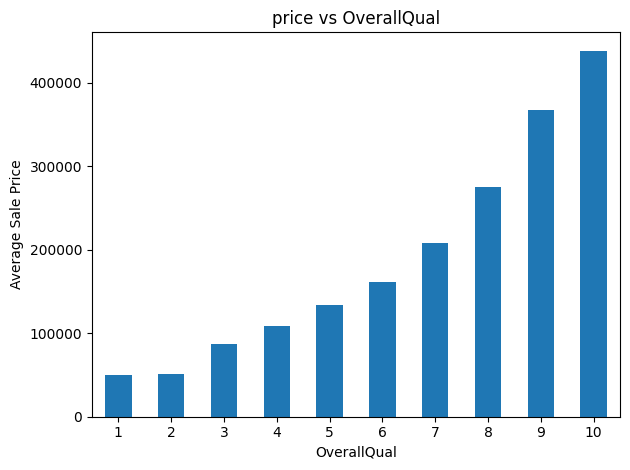

In [13]:
df.groupby('OverallQual')['SalePrice'].mean().plot(kind='bar')
plt.title("price vs OverallQual")
plt.ylabel("Average Sale Price")

plt.xlabel("OverallQual")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This plot illustrates the correlation between Overall Quality (OverallQual) and house price. It displays the average sale price for each category of OverallQual, highlighting a clear positive relationship.

Distribution Living Area and Sale Price

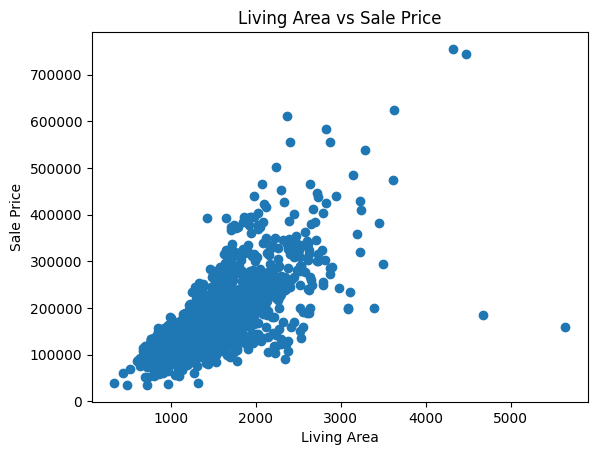

In [59]:
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel("Living Area")
plt.ylabel("Sale Price")
plt.title("Living Area vs Sale Price")
plt.show()

Distribution House Age and Sale Price

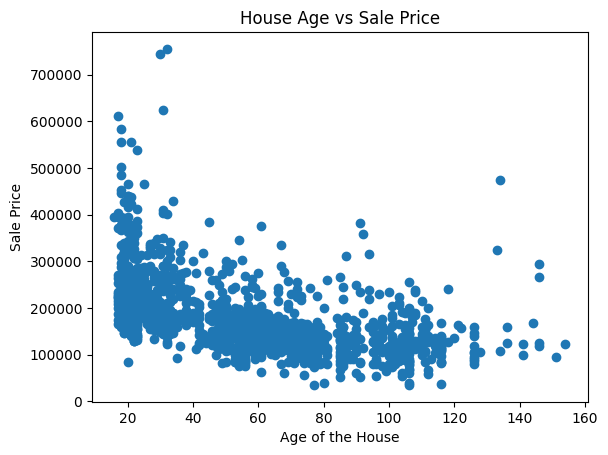

In [15]:
df['HouseAge'] = 2026 - df['YearBuilt']
plt.scatter(df['HouseAge'], df['SalePrice'])
plt.xlabel("Age of the House")
plt.ylabel("Sale Price")
plt.title("House Age vs Sale Price")
plt.show()

The analysis shows a negative relationship between property age and price, suggesting that newer houses are typically associated with higher market values.




#### Clustering based price

create a clustering splittinng the target in:
- low-end
- mid-range
- high-end

In [16]:
df['PriceSegment'] = pd.qcut(df['SalePrice'], q=3, labels=['Low', 'Mid', 'High'])
df.groupby('PriceSegment')['GrLivArea'].mean()

PriceSegment
Low     1153.975359
Mid     1442.232653
High    1954.238095
Name: GrLivArea, dtype: float64

#### Luxury score

The variables OverallQual, FullBath, and GarageCars can be combined to create a synthetic index, referred to as the Luxury Score, which captures the overall level of property luxury.

In [17]:
df['LuxuryScore'] = df['OverallQual'] +  df['FullBath']+ df['GarageCars']
df.groupby('LuxuryScore')['SalePrice'].mean()

LuxuryScore
1      61000.000000
2      39300.000000
3      47655.500000
4      65342.857143
5      92733.000000
6     104563.240000
7     123446.409483
8     135275.406393
9     155858.177083
10    181905.964286
11    207653.221344
12    251313.241071
13    295713.300000
14    367995.575758
15    429306.941176
16    549706.000000
Name: SalePrice, dtype: float64

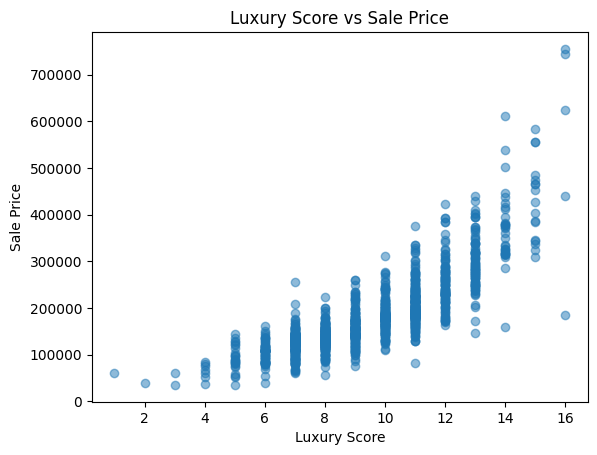

In [18]:
plt.scatter(df['LuxuryScore'], df['SalePrice'], alpha=0.5)
plt.xlabel("Luxury Score")
plt.ylabel("Sale Price")
plt.title("Luxury Score vs Sale Price")
plt.show()

A correlation can be observed between the newly constructed Luxury Score index and property price.

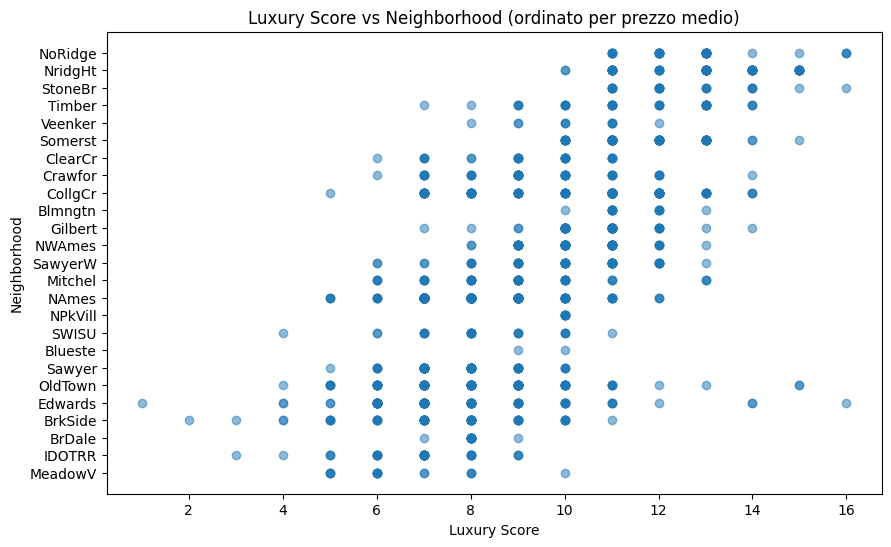

In [19]:
# 1. calcola l’ordine dei quartieri per prezzo medio
order = (
    df.groupby('Neighborhood')['SalePrice']
      .mean()
      .sort_values()
      .index
)

# 2. imposta la colonna come categorica ordinata
df['Neighborhood'] = pd.Categorical(
    df['Neighborhood'],
    categories=order,
    ordered=True
)

# 3. ordina il dataframe
df_sorted = df.sort_values('Neighborhood')

# 4. plot
plt.figure(figsize=(10,6))
plt.scatter(df_sorted['LuxuryScore'], df_sorted['Neighborhood'], alpha=0.5)

plt.xlabel("Luxury Score")
plt.ylabel("Neighborhood")
plt.title("Luxury Score vs Neighborhood (ordinato per prezzo medio)")
plt.show()

A more detailed examination of Luxury Score by neighborhood reveals a clear pattern: the most expensive areas also exhibit the highest Luxury Scores, suggesting consistency between property quality and market value.

#### Market Average

In [20]:
avg_price = df['SalePrice'].mean()

neigh = df.groupby('Neighborhood')['SalePrice'].mean()

neigh_premium = (neigh - avg_price) / avg_price * 100
avg_price, neigh_premium.sort_values(ascending=False).head(10)

(np.float64(180921.19589041095),
 Neighborhood
 NoRidge    85.326719
 NridgHt    74.811261
 StoneBr    71.621130
 Timber     33.896665
 Veenker    31.976094
 Somerst    24.573484
 ClearCr    17.490617
 Crawfor    16.417938
 CollgCr     9.420995
 Blmngtn     7.710366
 Name: SalePrice, dtype: float64)

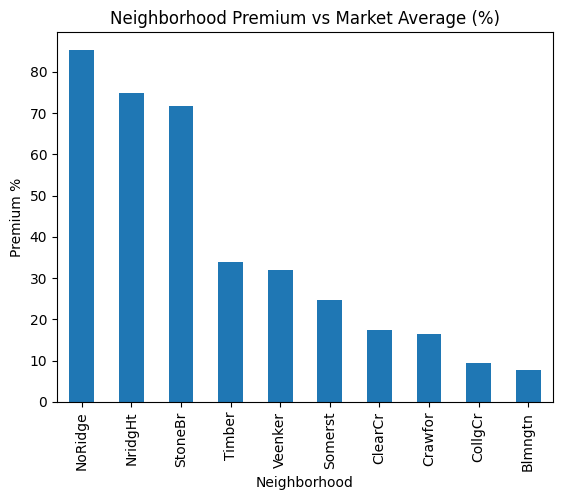

In [21]:
neigh_premium.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Neighborhood Premium vs Market Average (%)")
plt.ylabel("Premium %")
plt.show()

An analysis of average prices by neighborhood reveals significant geographical variations. The neighborhoods of NoRidge (+85%), NridgHt (+75%), and StoneBr (+72%) command the highest price premiums relative to the market average, indicating that location is one of the key factors influencing property values.

### Predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#### Feature Selection and Dataset Construction

In [70]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt"
]
df_ml = df[features + ["SalePrice"]]

#### Feature-Target Split 

In [71]:
X = df_ml[features]
y = df_ml["SalePrice"]



#### Train-Test Split

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#### Linear Regression

In [73]:
lr = LinearRegression()

lr.fit(X_train, y_train)

print(f"Intercept: {lr.intercept_:.2f}")
for i in range(len(features)):
    print(f"{features[i]}: {lr.coef_[i]:.2f}")


y_pred_lr = lr.predict(X_test)

Intercept: -759894.32
OverallQual: 20507.20
GrLivArea: 51.99
GarageCars: 15329.41
TotalBsmtSF: 24.48
FullBath: -5421.21
YearBuilt: 350.91


Although FullBath shows a negative coefficient in the linear model, this is likely due to multicollinearity between housing features such as size, quality, and number of bathrooms.

In [74]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print('MAE (Mean Absolute Error):       ', mae_lr)
print('RMSE (Root Mean Squared Error):  ', rmse_lr)
print('R² (R-squared):                  ', r2_lr)

MAE (Mean Absolute Error):        25319.860444313614
RMSE (Root Mean Squared Error):   39710.99035385876
R² (R-squared):                   0.7944073417103639


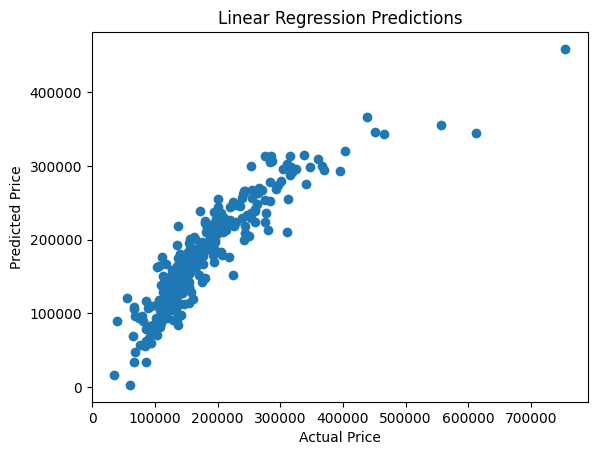

In [75]:
plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Linear Regression Predictions")

plt.show()

#### RandomForest

In [76]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [77]:
mae_rf = mean_absolute_error(y_test, y_pred_lr)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print('MAE (Mean Absolute Error):       ', mae_rf)
print('RMSE (Root Mean Squared Error):  ', rmse_rf)
print('R² (R-squared):                  ', r2_rf)

MAE (Mean Absolute Error):        25319.860444313614
RMSE (Root Mean Squared Error):   39710.99035385876
R² (R-squared):                   0.890782574538937


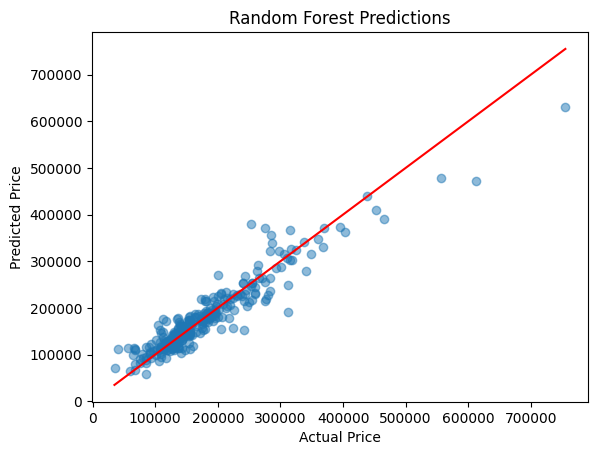

In [78]:
plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Predictions")

plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')

plt.show()

In [79]:
for i, feature in enumerate(features):
    print(f"{feature}: {rf.feature_importances_[i]:.2f}")

OverallQual: 0.58
GrLivArea: 0.20
GarageCars: 0.03
TotalBsmtSF: 0.11
FullBath: 0.01
YearBuilt: 0.06
